In [1]:
import numpy as np
import pandas as pd
from skimage import io

from glob import glob
from os import path
import seaborn as sb
import matplotlib.pyplot as plt

from functools import reduce
from twophotonUtils import parse_XML_timestamps
from skimage import draw


In [14]:
experiment_dirname='/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/mTmG clones/05-29-2026 mTmG clone rep2/DOB 03-22-2026'
# experiment_dirname = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/01-26-2026 mTmG'
dx = 0.58 # microns per pixel
dz = 1


In [15]:
manifest = []
# Parse filestructure
mice_dirs = glob(path.join(experiment_dirname,'*'))
timestamps = {}

for m in mice_dirs:
    mouse = path.split(m)[1]
    for r in glob(path.join(m,'*R*')):
        region = path.split(r)[1]
        print(r)
        
        timestamps[mouse+'_'+region] = parse_XML_timestamps(r)

        for c in glob(path.join(r,'Clones/*.csv')):
            clone = path.splitext(path.split(c)[1])[0]
            manifest.append({'Mouse':mouse,'Region':region,
                             'dirname':r,'filename':c,'Clone':clone,})
        
manifest = pd.DataFrame(manifest)
manifest['Mouse_Region'] = manifest['Mouse'] + '_' + manifest['Region']
manifest['Mouse_Region'].unique()

/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/mTmG clones/05-29-2026 mTmG clone rep2/DOB 03-22-2026/F1 tail clip/R1
/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/mTmG clones/05-29-2026 mTmG clone rep2/DOB 03-22-2026/F1 tail clip/R3
/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/mTmG clones/05-29-2026 mTmG clone rep2/DOB 03-22-2026/F1 tail clip/R4
/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/mTmG clones/05-29-2026 mTmG clone rep2/DOB 03-22-2026/F1 tail clip/R2
/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/mTmG clones/05-29-2026 mTmG clone rep2/DOB 03-22-2026/M1 tail clip/R1
/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/mTmG clones/05-29-2026 mTmG clone rep2/DOB 03-22-2026/M1 tail clip/R3
/Users/xies/Library/CloudStorage/OneDrive-Stan

array(['F1 tail clip_R1', 'F1 tail clip_R3', 'F1 tail clip_R2',
       'M1 tail clip_R1', 'M1 tail clip_R2'], dtype=object)

In [16]:
from measurements import get_bm_image
from collections import defaultdict
# Calculate the curvatures
overwrite = False

sigmas = [5/dz,5/dx,5/dx]

kwds = defaultdict(dict)
kwds[('F1 tail clip_R1',4)] = {'method':'maximum'}
kwds[('F1 tail clip_R2',3)] = {'method':'maximum'}
kwds[('F1 tail clip_R3',4)] = {'method':'maximum'}
kwds[('M1 tail clip_R1',0)] = {'method':'maximum'}
kwds[('M1 tail clip_R2',0)] = {'method':'maximum'}

for m in mice_dirs:
    mouse = path.split(m)[1]
    for r in glob(path.join(m,'*R*')):
        region = path.split(r)[1]
        ID = f'{mouse} {region}'
        print(ID)
    
        if path.exists(path.join(r,'height_image.tif')) and not overwrite:
            continue
        else:
            # Calculate basement membranes
            B = io.imread(path.join(r,'B_align.tif'))
            bm = np.zeros_like(B)
            h = np.zeros((5,1024,1024))
            for t,this_day in enumerate(B):
                
                h[t,...],bm[t,...] = get_bm_image(this_day,sigmas=sigmas,gradient_sign=+1,
                                                          **kwds[(ID,t)])

            io.imsave(path.join(r,'heightmaps.tif'),h)
            io.imsave(path.join(r,'height_image.tif'),bm)
            

F1 tail clip R1


/Users/xies/Desktop/Code/mouse_skin_size_control/utils/measurements.py:172: RuntimeWarning: invalid value encountered in cast
  interpolate.griddata(np.array([Y,X]).T,Z,(grid_y,grid_x), method='linear')).astype(int).T


KeyboardInterrupt: 

In [7]:
# Manually put in reference frames. Default is t=0

references = defaultdict(list)
references['F1 tail clip_R1'] = 1
references['F1 tail clip_R2'] = 1
references['F1 DOB 12-5-2025_Left paw R2'] = 1
references['F2 DOB 12-5-2025_Left paw R2'] = 1
# references['F2 DOB 12-5-2025_Left paw R1'] = 2
references['M2 DOB 12-5-2025_Left paw R1'] = 1


In [8]:
# Calculate the 'reference curvature'
from measurements import get_mesh_from_bm_image, get_tissue_curvature_over_grid
overwrite = False

curvatures = {}
for regionID,region in manifest.groupby(['Mouse_Region']):

    regionID = regionID[0]
    print(regionID)
    if path.exists(path.join(region.iloc[0]['dirname'],'reference_curvature.npz')) and not overwrite:
        curvatures[regionID] = np.load(path.join(region.iloc[0]['dirname'],'reference_curvature.npz'))['reference_curvature']
    else:
    
        if references[regionID] == []:
            reference_frame = 0
        else:
            reference_frame = references[regionID]
    
        print((regionID, reference_frame))
        
        bm = io.imread(path.join(region.iloc[0]['dirname'],'height_image.tif'))[reference_frame]
        mesh = get_mesh_from_bm_image(bm,spacing=[dz,dx,dx],decimation_factor=15)
        meanC,gaussC = get_tissue_curvature_over_grid(mesh, bm.shape, spacing=[dz,dx,dx])
        # meanC = meanC.T
        curvatures[regionID] = meanC
        
        np.savez(path.join(region.iloc[0]['dirname'],'reference_curvature'),reference_curvature=meanC)
        from skimage import draw

polys = {}
masks = {}
for regionID,region in manifest.groupby('Mouse_Region'):
    regionID = regionID
    polys[regionID] = pd.read_csv(path.join(region.iloc[0]['dirname'],'mask.csv'))
    masks[regionID] = draw.polygon2mask([1024,1024],polys[regionID][['axis-0','axis-1']]).T
# len(list(masks.keys()))

F1 DOB 12-5-2025_Left paw R1
F1 DOB 12-5-2025_Left paw R2
F1 DOB 12-5-2025_Left paw R3
F2 DOB 12-5-2025_Left paw R1
F2 DOB 12-5-2025_Left paw R2
F2 DOB 12-5-2025_Left paw R3
M1 DOB 12-5-2025_Left paw R1
M1 DOB 12-5-2025_Left paw R2
M1 DOB 12-5-2025_Left paw R3
M2 DPB 12-5-2025_Left paw R1
M2 DPB 12-5-2025_Left paw R2


In [10]:
# Load the clones .csvs

raw_clones = []
for idx,c in manifest.iterrows():
    data = pd.read_csv(c['filename'],index_col=0)
    data = data.rename(columns={'axis-0':'Frame','axis-1':'Z','axis-2':'Y','axis-3':'X'})
    raw_clones.append(data)

# Parse clone # and QC for clone physical distance (should be small)
clone_counts = []
for i,clone in enumerate(raw_clones):
    this_count = pd.merge(clone.groupby('Frame').mean()[['Z','Y','X']].reset_index(drop=True),
                          clone.groupby('Frame').count().reset_index()[['Frame','Z']].rename(columns={'Z':'Count'}),
                          left_index=True,right_index=True)
    this_count[['Mouse','Region','Clone','Mouse_Region']] = \
        manifest.iloc[i][['Mouse','Region','Clone','Mouse_Region']]
    refT = references[manifest.iloc[i]['Mouse_Region']]
    if refT == []:
        refT = 0
    
    this_count['reference'] = refT
    clone_counts.append(this_count)

clone_counts = pd.concat(clone_counts,ignore_index=True)
clone_counts['UniqueID'] = clone_counts['Mouse'] + '_' + clone_counts['Region'] + '_' + clone_counts['Clone']


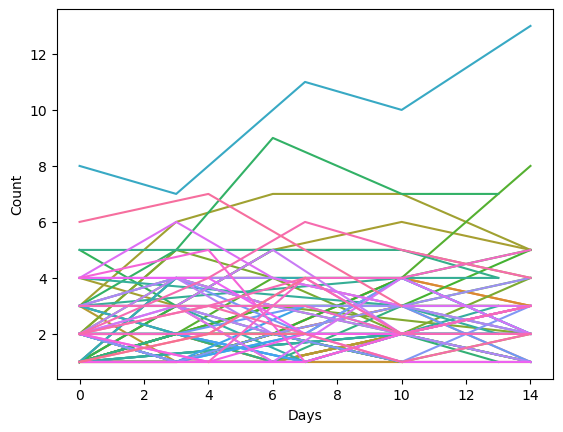

In [11]:
# Parse time stamps into delta times

# timestamps
df = []
for ID,clone in clone_counts.groupby('UniqueID'):
    ts = timestamps[clone.iloc[0]['Mouse_Region']]
    ts = [t - ts[0] for t in ts.values()]
    clone['Days'] = [ts[int(t)].days for t in clone['Frame']]
    df.append(clone)
    
df = pd.concat(df,ignore_index=True)

g = sb.lineplot(df,x='Days',y='Count',hue='UniqueID',legend=False)
# sb.move_legend(g,(0,1))

In [12]:
# Parse final clone size change from initial size
counted = []
for i,clone in df.groupby('UniqueID'):
    if len(clone) < 5:
        size_change = -clone.iloc[0]['Count']
    else:
        size_change = clone.iloc[-1]['Count'] - clone.iloc[0]['Count']
    clone['Initial size'] = clone.iloc[0]['Count']
    clone['Size change'] = clone['Count'] - clone.iloc[0]['Count']
    clone['Final size change'] = size_change
    clone['Extinction time'] = clone.iloc[-1]['Days']
    clone['UniqueID'] = i
    
    counted.append(clone)

df = pd.concat(counted,ignore_index=True)
df

,Z,Y,X,Frame,Count,Mouse,Region,Clone,Mouse_Region,reference,UniqueID,Days,Initial size,Size change,Final size change,Extinction time
0,58.0,767.901095,445.712444,0.0,1,F1 DOB 12-5-2025,Left paw R1,Clone1,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone1,0,1,0,-1,3
1,52.0,838.146998,321.098136,1.0,1,F1 DOB 12-5-2025,Left paw R1,Clone1,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone1,3,1,0,-1,3
2,55.0,528.149487,959.598983,0.0,1,F1 DOB 12-5-2025,Left paw R1,Clone10,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone10,0,1,0,0,14
3,54.0,617.090124,874.777493,1.0,1,F1 DOB 12-5-2025,Left paw R1,Clone10,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone10,3,1,0,0,14
4,56.0,532.298201,977.818113,2.0,2,F1 DOB 12-5-2025,Left paw R1,Clone10,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone10,6,1,1,0,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,57.5,296.391026,511.461676,1.0,2,M2 DPB 12-5-2025,Left paw R2,Clone8,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone8,4,1,1,-1,7
408,54.0,251.292945,483.541177,2.0,4,M2 DPB 12-5-2025,Left paw R2,Clone8,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone8,7,1,3,-1,7
409,66.0,128.370061,592.317710,0.0,1,M2 DPB 12-5-2025,Left paw R2,Clone9,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone9,0,1,0,-1,7
410,64.0,197.729683,524.494213,1.0,2,M2 DPB 12-5-2025,Left paw R2,Clone9,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone9,4,1,1,-1,7


In [52]:
X

592

In [66]:
# Load tissue curvatures

df_curv = []
for i,clone in df.groupby('UniqueID'):

    ref = int(clone.iloc[0]['reference'])
    
    if ref in clone.set_index('Frame').index:
        Y,X = (clone.set_index('Frame').loc[ref][['Y','X']]).astype(int)
        C = curvatures[clone.iloc[0]['Mouse_Region']].copy()
        mask = masks[clone.iloc[0]['Mouse_Region']]
        C[~mask] = np.nan
        initC = np.nanmean(C[Y-10:Y+10,X-10:X+10])
    else:
        initC = np.nan
        
    clone['Initial curvature'] = initC
    df_curv.append(clone)
    
df = pd.concat(df_curv,ignore_index=True)

/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_65710/2662319457.py:13: RuntimeWarning: Mean of empty slice
  initC = np.nanmean(C[Y-10:Y+10,X-10:X+10])
/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_65710/2662319457.py:13: RuntimeWarning: Mean of empty slice
  initC = np.nanmean(C[Y-10:Y+10,X-10:X+10])
/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_65710/2662319457.py:13: RuntimeWarning: Mean of empty slice
  initC = np.nanmean(C[Y-10:Y+10,X-10:X+10])
/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_65710/2662319457.py:13: RuntimeWarning: Mean of empty slice
  initC = np.nanmean(C[Y-10:Y+10,X-10:X+10])
/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_65710/2662319457.py:13: RuntimeWarning: Mean of empty slice
  initC = np.nanmean(C[Y-10:Y+10,X-10:X+10])


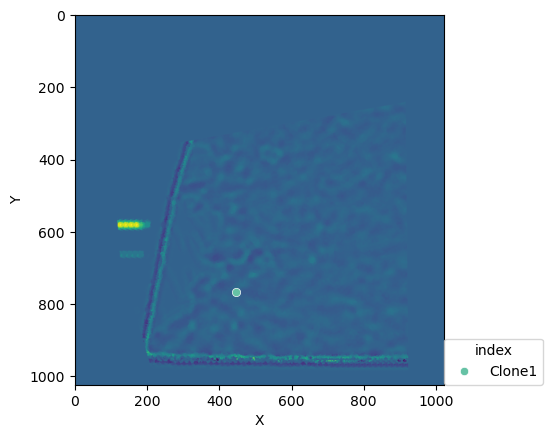

In [61]:
region = 'F1 DOB 12-5-2025_Left paw R1'
plt.imshow(curvatures[region].T*masks[region].T)

pd.DataFrame({ID:c[['X','Y']].mean() for ID,c in clone_counts.set_index('Mouse_Region').loc[region].groupby('Clone')}).T.reset_index()

g = sb.scatterplot( pd.DataFrame({ID:c.set_index('Frame').loc[0][['X','Y']]
                                  for ID,c in clone_counts.set_index('Mouse_Region').loc[region].groupby('Clone')}).T.reset_index().iloc[0:1],
              x='X',y='Y',hue='index',palette='Set2')
sb.move_legend(g,[1,0])

In [67]:
# pd.DataFrame([clone for _,clone in df.groupby('UniqueID')])
df_unique = pd.DataFrame([c.iloc[0] for _,c in df.groupby('UniqueID')])
df_unique.set_index('UniqueID').loc['F1 DOB 12-5-2025_Left paw R1_Clone1']

Z                                            58.0
Y                                      767.901095
X                                      445.712444
Frame                                         0.0
Count                                           1
Mouse                            F1 DOB 12-5-2025
Region                                Left paw R1
Clone                                      Clone1
Mouse_Region         F1 DOB 12-5-2025_Left paw R1
reference                                       0
Days                                            0
Initial size                                    1
Size change                                     0
Final size change                              -1
Extinction time                                 3
Initial curvature                        0.015812
Name: F1 DOB 12-5-2025_Left paw R1_Clone1, dtype: object

In [68]:
from basicUtils import nonan_pairs
from scipy.stats import pearsonr
X,Y = nonan_pairs(df_unique['Initial curvature'],df_unique['Final size change'])
R = pearsonr(X,Y)
print(len(X))
R

96


PearsonRResult(statistic=np.float64(0.1644196117064908), pvalue=np.float64(0.10942377861904612))

In [69]:
df_unique[df_unique['Initial curvature']> 0.8]

,Z,Y,X,Frame,Count,Mouse,Region,Clone,Mouse_Region,reference,UniqueID,Days,Initial size,Size change,Final size change,Extinction time,Initial curvature


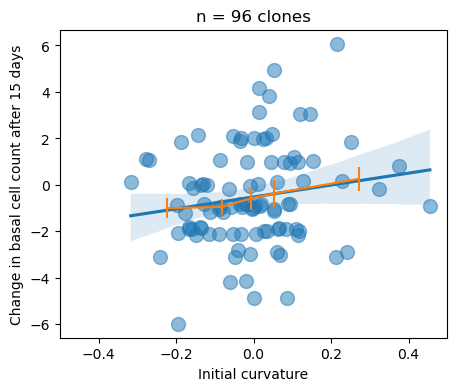

In [70]:
from basicUtils import plot_bin_means
unique = [c.iloc[0] for _,c in df.groupby('UniqueID')]
unique = pd.DataFrame(unique)

fig = plt.figure(figsize=[5,4])
plt.title(f'n = {len(df_unique.dropna())} clones')
sb.regplot(unique,x='Initial curvature',y='Final size change',y_jitter=0.2, scatter_kws={'alpha':0.5,'s':100})

plot_bin_means(unique['Initial curvature'],unique['Final size change'],bin_edges=6,mean='mean',minimum_n=5,bin_style='percentile')
plt.ylabel('Change in basal cell count after 15 days')
plt.xlim([-.5,.5])

fig.savefig(path.join(experiment_dirname,'Figures/curvature_v_size_change.svg'))

In [58]:
df_unique

,Z,Y,X,Frame,Count,Mouse,Region,Clone,Mouse_Region,reference,UniqueID,Days,Initial size,Size change,Final size change,Extinction time,Initial curvature
0,58.0,767.901095,445.712444,0.0,1,F1 DOB 12-5-2025,Left paw R1,Clone1,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone1,0,1,0,-1,3,1.581192e-02
2,55.0,528.149487,959.598983,0.0,1,F1 DOB 12-5-2025,Left paw R1,Clone10,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone10,0,1,0,0,14,-3.170185e-01
7,51.0,773.942356,347.663333,0.0,1,F1 DOB 12-5-2025,Left paw R1,Clone11,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone11,0,1,0,-1,0,-3.769943e-03
8,62.0,437.778438,237.625453,0.0,1,F1 DOB 12-5-2025,Left paw R1,Clone12,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone12,0,1,0,-1,3,NaN
10,59.0,143.443798,689.456556,0.0,1,F1 DOB 12-5-2025,Left paw R1,Clone13,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone13,0,1,0,2,14,3.087798e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396,61.0,712.193860,531.039177,0.0,2,M2 DPB 12-5-2025,Left paw R2,Clone5,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone5,0,2,0,0,14,-1.654393e-01
401,64.0,321.554240,872.827160,0.0,1,M2 DPB 12-5-2025,Left paw R2,Clone6,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone6,0,1,0,-1,0,9.394900e-02
402,59.0,356.642388,616.315095,0.0,6,M2 DPB 12-5-2025,Left paw R2,Clone7,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone7,0,6,0,-6,10,-1.947559e-01
406,58.0,224.763251,587.408035,0.0,1,M2 DPB 12-5-2025,Left paw R2,Clone8,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone8,0,1,0,-1,7,5.337596e-02


,Z,Y,X,Frame,Count,Mouse,Region,Clone,Mouse_Region,reference,UniqueID,Days,Initial size,Size change,Final size change,Extinction time,Initial curvature
Concavity,,,,,,,,,,,,,,,,,
False,66,66,66,66,66,66,66,66,66,66,66,66,66,66,66,66,50
True,46,46,46,46,46,46,46,46,46,46,46,46,46,46,46,46,46


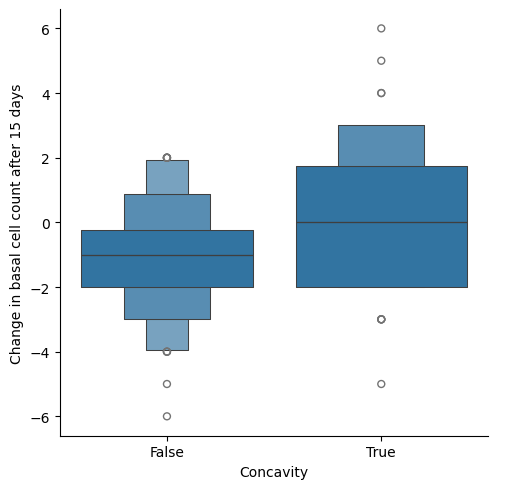

In [72]:
from basicUtils import ttest_from_groupby

df_unique['Concavity'] = df_unique['Initial curvature'] >= 0
sb.catplot(df_unique,x='Concavity',y='Final size change',kind='boxen')
plt.ylabel('Change in basal cell count after 15 days')

plt.savefig(path.join(experiment_dirname,'Figures/convexity_v_size_change.svg'))
ttest_from_groupby(df_unique,field2group='Concavity',field2test='Final size change')
df_unique.groupby('Concavity').count()

In [27]:
df = pd.merge(df,df_unique[['Concavity','UniqueID']],left_on='UniqueID',right_on='UniqueID')


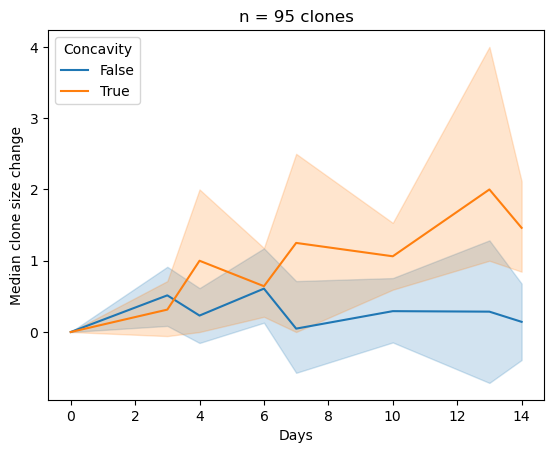

In [28]:
plt.title(f'n = {len(df_unique.dropna())} clones')
g = sb.lineplot(df,x='Days',y='Size change',hue='Concavity')
plt.ylabel('Median clone size change')

plt.savefig(path.join(experiment_dirname,'Figures/curvature_v_size_change_timeseries.svg'))

,Z,Y,X,Frame,Count,Mouse,Region,Clone,Mouse_Region,reference,UniqueID,Days,Initial size,Size change,Final size change,Extinction time,Initial curvature,Concavity
0,58.0,767.901095,445.712444,0.0,1,F1 DOB 12-5-2025,Left paw R1,Clone1,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone1,0,1,0,-1,3,1.016346e-02,True
2,55.0,528.149487,959.598983,0.0,1,F1 DOB 12-5-2025,Left paw R1,Clone10,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone10,0,1,0,0,14,-4.420355e-01,False
7,51.0,773.942356,347.663333,0.0,1,F1 DOB 12-5-2025,Left paw R1,Clone11,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone11,0,1,0,-1,0,-2.364859e-02,False
10,59.0,143.443798,689.456556,0.0,1,F1 DOB 12-5-2025,Left paw R1,Clone13,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone13,0,1,0,2,14,3.474013e-08,True
19,59.0,827.726097,596.548168,0.0,2,F1 DOB 12-5-2025,Left paw R1,Clone2,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone2,0,2,0,-2,6,-2.378876e-01,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,56.0,297.119817,490.820783,0.0,2,M2 DPB 12-5-2025,Left paw R2,Clone4,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone4,0,2,0,2,14,3.249429e-01,True
396,61.0,712.193860,531.039177,0.0,2,M2 DPB 12-5-2025,Left paw R2,Clone5,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone5,0,2,0,0,14,-1.660713e-01,False
401,64.0,321.554240,872.827160,0.0,1,M2 DPB 12-5-2025,Left paw R2,Clone6,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone6,0,1,0,-1,0,1.611067e-01,True
402,59.0,356.642388,616.315095,0.0,6,M2 DPB 12-5-2025,Left paw R2,Clone7,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone7,0,6,0,-6,10,-1.892009e-01,False
